In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [2]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [3]:
from torchvision import datasets, transforms

data_path = "./data-unversioned/p1ch8/"
cifar10 = datasets.CIFAR10(
    data_path,
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616)),
        ]
    ),
)

100%|██████████| 170M/170M [00:05<00:00, 30.7MB/s]


Extracting ./data-unversioned/p1ch8/cifar-10-python.tar.gz to ./data-unversioned/p1ch8/


In [4]:
!ls -al ./data-unversioned/p1ch8

total 166516
drwxr-xr-x 3 root root      4096 Feb 22 05:45 .
drwxr-xr-x 4 root root      4096 Feb 22 05:45 ..
drwxr-xr-x 2 2156 1103      4096 Jun  4  2009 cifar-10-batches-py
-rw-r--r-- 1 root root 170498071 Feb 22 05:45 cifar-10-python.tar.gz


In [5]:
cifar10_val = datasets.CIFAR10(
    data_path,
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616)),
        ]
    ),
)

Files already downloaded and verified


len(cifar2): 10000
len(cifar2_val): 2000
img: torch.Size([3, 32, 32])
lebel: 1
img: torch.Size([3, 32, 32])
lebel: 0


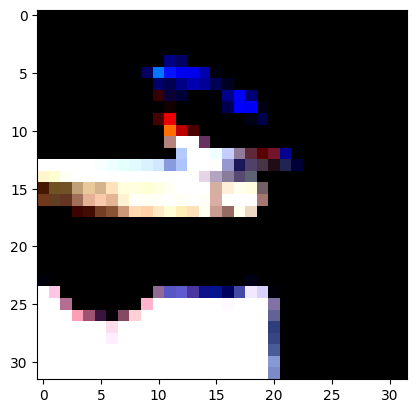

In [6]:
label_map = {0: 0, 2: 1}
class_names = ["airplane", "bird"]
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

print("len(cifar2):", len(cifar2))
print("len(cifar2_val):", len(cifar2_val))

img, lebel = cifar2[1]
print("img:", img.shape)
print("lebel:", lebel)
plt.imshow(img.permute(1, 2, 0))

img, lebel = cifar2_val[1]
print("img:", img.shape)
print("lebel:", lebel)
plt.show()

In [7]:
connected_model = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2),
)

In [8]:
numel_list = [p.numel() for p in connected_model.parameters()]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

In [9]:
numel_list = [
    p.numel() for p in connected_model.parameters() if p.requires_grad == True
]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

In [10]:
first_model = nn.Sequential(
    nn.Linear(3072, 512), nn.Tanh(), nn.Linear(512, 2), nn.LogSoftmax(dim=1)
)

In [11]:
numel_list = [p.numel() for p in first_model.parameters()]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

In [12]:
numel_list = [p.numel() for p in first_model.parameters() if p.requires_grad == True]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

In [13]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))

In [14]:
"""
torch.nn 模块提供一维、二维、 三维的卷积, 其中 nn.Conv1d 用于时间序列, nn.Conv2d 用于图像, nn.Conv3d 用于视频.
对于 CIFAR-10 数据, 我们将求助于 nn.Conv2d.
提供给 nn.Conv2d 的参数至少包括输入特征(既通道, 因为我们处理的是多通道图像)的数量、输出特征的数量以及核的大小等.
例如, 对于第 1 个卷积模块, 每个像素有 3 个输入特征(RGB 通道), 输出特征具有任意数量的通道数, 如有 16 个通道. 输出图像的通道越多, 表示网络的容量越大, 我们借助这些通道能够检测到许多不同类型的特征.
另外, 由于我们是随机对它们进行初始化的, 因此我们得到的一些特征, 即使经过训练, 也是无用的 1.
让我们使用 3 x 3 的卷积核
"""

conv = nn.Conv2d(
    3, 16, kernel_size=3
)  # 我们可以传入在输出中看到的元组: kernel_size=(3, 3), 而不使用快捷方式 kernel_size=3
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [15]:
# 完整的权重张量是 out_ch x in_ch x 3 x 3
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [16]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

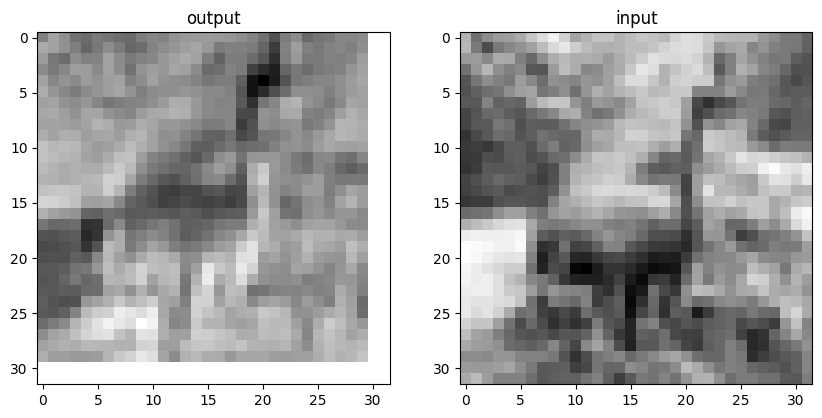

In [17]:
plt.figure(figsize=(10, 4.8))

ax1 = plt.subplot(1, 2, 1)
plt.title("output")
plt.imshow(output[0, 0].detach(), cmap="gray")

ax2 = plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
plt.title("input")
plt.imshow(img.mean(0), cmap="gray")

plt.show()

In [18]:
# 填充边界
# conv = nn.Conv2d(3, 16, kernel_size=3)
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
conv

Conv2d(3, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [19]:
conv.weight.shape, conv.bias.shape

(torch.Size([1, 3, 3, 3]), torch.Size([1]))

In [20]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

In [21]:
# 为了消除所有干扰因素, 让我们首先将偏置归零, 然后将权重设置为一个常数值, 这样输出中的每个像素都能得到其相邻像素的均值
with torch.no_grad():
    conv.bias.zero_()

with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

In [22]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

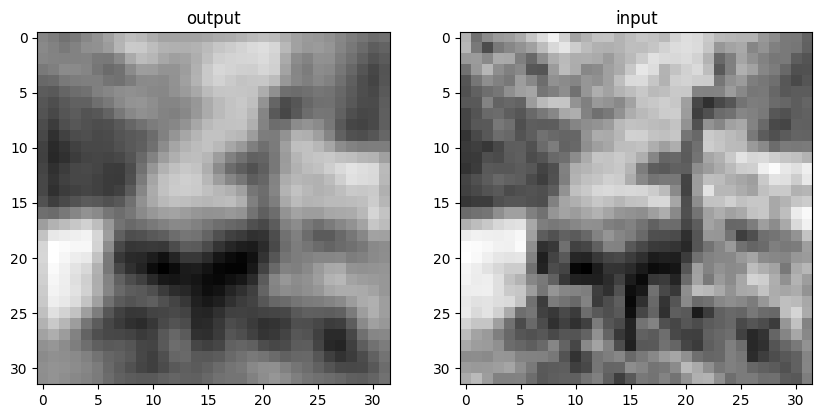

In [23]:
plt.figure(figsize=(10, 4.8))

ax1 = plt.subplot(1, 2, 1)
plt.title("output")
plt.imshow(output[0, 0].detach(), cmap="gray")

ax2 = plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
plt.title("input")
plt.imshow(img.mean(0), cmap="gray")

plt.show()

In [24]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor(
        [[-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0]]
    )
    conv.bias.zero_()

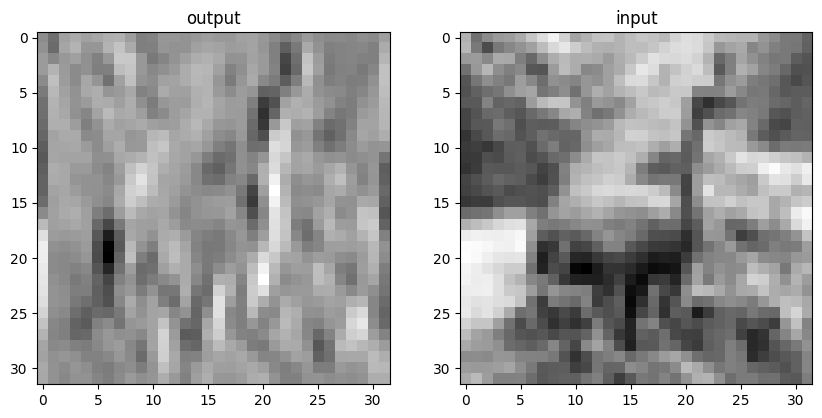

In [25]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))

plt.figure(figsize=(10, 4.8))

ax1 = plt.subplot(1, 2, 1)
plt.title("output")
plt.imshow(output[0, 0].detach(), cmap="gray")

ax2 = plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
plt.title("input")
plt.imshow(img.mean(0), cmap="gray")

plt.show()

In [26]:
# 池化
pool = nn.MaxPool2d(2)

img, _ = cifar2[0]
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

In [27]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    # ...  # 警告: 这里缺少了一些重要的东西!
)

In [28]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    # ... # 警告: 这里缺少了一些重要的东西!
    nn.Linear(8 * 8 * 8, 32),
    nn.Tanh(),
    nn.Linear(32, 2),
)

In [29]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [30]:
img, _ = cifar2[0]
output = model(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x8 and 512x32)

In [31]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8)  # 这是我们之前所缺少的
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [32]:
model = Net()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [33]:
img, _ = cifar2[0]
output = model(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 2]))

In [34]:
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [35]:
model = Net()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [36]:
img, _ = cifar2[0]
output = model(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 2]))

In [39]:
# 训练我们的 convnet
import datetime

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")


def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(
        1, n_epochs + 1
    ):  # 我们的循环遍历从 1 到 n_epochs, 而不是从 0 开始的
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print(
                "{} Epoch {}, Training loss {}".format(
                    datetime.datetime.now(), epoch, loss_train / len(train_loader)
                )
            )

Training on device cuda.


In [40]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

model = Net()
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)

Training on device cuda.
2025-02-22 05:51:58.622495 Epoch 1, Training loss 0.5783971922033152
2025-02-22 05:52:02.432028 Epoch 10, Training loss 0.33745697558305826
2025-02-22 05:52:06.238540 Epoch 20, Training loss 0.30088192575676426
2025-02-22 05:52:10.235919 Epoch 30, Training loss 0.2747955686727147
2025-02-22 05:52:14.401195 Epoch 40, Training loss 0.24965403366620373
2025-02-22 05:52:18.264409 Epoch 50, Training loss 0.22794806852841834
2025-02-22 05:52:22.314520 Epoch 60, Training loss 0.2106166525631194
2025-02-22 05:52:26.446508 Epoch 70, Training loss 0.19290764207483097
2025-02-22 05:52:30.367605 Epoch 80, Training loss 0.180592861999372
2025-02-22 05:52:34.409027 Epoch 90, Training loss 0.16838975091743622
2025-02-22 05:52:38.467162 Epoch 100, Training loss 0.15454986893162606


In [42]:
# 测量精度
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")


def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Accuracy {}: {:.2f}".format(name, correct / total))


validate(model, train_loader, val_loader)

Training on device cuda.
Accuracy train: 0.93
Accuracy val: 0.89


In [44]:
# 保存并加载我们的模型
model.to("cpu")
torch.save(model.state_dict(), data_path + "birds_vs_airplanes.pt")

In [45]:
loaded_model = Net()
loaded_model.load_state_dict(torch.load(data_path + "birds_vs_airplanes.pt"))

<ipython-input-45-86454dc744d1>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(data_path + "birds_vs_airplanes.pt"))


<All keys matched successfully>

In [46]:
img, _ = cifar2[0]
output = model(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 2]))

In [47]:
# 在 GPU 上训练
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cuda.


In [48]:
import datetime


def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(
                device=device
            )  # 这 2 行代码将 imgs 和 labels 移动到我们正在训练的设备上, 这是现在的代码与以前版本唯一的区别
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print(
                "{} Epoch {}, Training loss {}".format(
                    datetime.datetime.now(), epoch, loss_train / len(train_loader)
                )
            )

In [49]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

# 将我们的模型(所有参数)移动到 GPU. 如果你忘记将模型或输入移动到 GPU, 你会得到张量不在同一设备上的错误, 因为 PyTorch 不支持 GPU 和 CPU 的混合输入
model = Net().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)

2025-02-22 05:56:54.156165 Epoch 1, Training loss 0.6123988019053344
2025-02-22 05:56:57.654146 Epoch 10, Training loss 0.3370863435564527
2025-02-22 05:57:01.949521 Epoch 20, Training loss 0.2970143084882931
2025-02-22 05:57:05.809786 Epoch 30, Training loss 0.268818171540643
2025-02-22 05:57:09.628819 Epoch 40, Training loss 0.2452433995285611
2025-02-22 05:57:13.880813 Epoch 50, Training loss 0.22864564797680847
2025-02-22 05:57:17.783763 Epoch 60, Training loss 0.21122797388749517
2025-02-22 05:57:21.589706 Epoch 70, Training loss 0.19816177243449887
2025-02-22 05:57:25.853954 Epoch 80, Training loss 0.18735466209376694
2025-02-22 05:57:29.720215 Epoch 90, Training loss 0.1703552307596632
2025-02-22 05:57:33.711414 Epoch 100, Training loss 0.15778693919823428


In [50]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
all_acc_dict = collections.OrderedDict()


def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)  # <1>
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Accuracy {}: {:.2f}".format(name, correct / total))
        accdict[name] = correct / total
    return accdict


all_acc_dict["baseline"] = validate(model, train_loader, val_loader)

Accuracy train: 0.90
Accuracy val: 0.85


In [53]:
"""
加载网络权重时有一点儿复杂: PyTorch 将尝试将权重加载到保存它的同一设备上.
也就是说, GPU 上的权重将恢复到 GPU 上. 由于我们不知道是否需要相同的设备, 我们有 2 个选择:
在保存之前将网络移动到 CPU, 或者在恢复后将其移回.
在加载权重时, 指示 PyTorch 覆盖设备信息会更简洁一些.
这是通过将 map_location 关键字参数传递给 torch.load 来实现的
"""

print(f"Training on device {device}.")
loaded_model = Net().to(device=device)
loaded_model.load_state_dict(
    torch.load(data_path + "birds_vs_airplanes_gpu.pt", map_location=device)
)

Training on device cuda.


<ipython-input-53-f10c2ef34f76>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(data_path + "birds_vs_airplanes_gpu.pt", map_location=device)


FileNotFoundError: [Errno 2] No such file or directory: './data-unversioned/p1ch8/birds_vs_airplanes_gpu.pt'

In [54]:
# 模型设计
class NetWidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 16 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [55]:
model = NetWidth().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)

validate(model, train_loader, val_loader)

2025-02-22 06:00:08.452334 Epoch 1, Training loss 0.5440223017695603
2025-02-22 06:00:12.015925 Epoch 10, Training loss 0.31594761304414953
2025-02-22 06:00:19.325408 Epoch 20, Training loss 0.2751596917392342
2025-02-22 06:00:24.823184 Epoch 30, Training loss 0.2396342907646659
2025-02-22 06:00:28.780794 Epoch 40, Training loss 0.20917624121258974
2025-02-22 06:00:33.226827 Epoch 50, Training loss 0.18191126919096443
2025-02-22 06:00:37.183974 Epoch 60, Training loss 0.15730388794734979
2025-02-22 06:00:41.125292 Epoch 70, Training loss 0.13439287276119943
2025-02-22 06:00:45.497396 Epoch 80, Training loss 0.11315886754613773
2025-02-22 06:00:49.568224 Epoch 90, Training loss 0.09406395199572205
2025-02-22 06:00:53.505556 Epoch 100, Training loss 0.07728069123758632
Accuracy train: 0.96
Accuracy val: 0.89


{'train': 0.9589, 'val': 0.8865}

In [56]:
class NetWidth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [57]:
model = NetWidth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)

all_acc_dict["width"] = validate(model, train_loader, val_loader)

2025-02-22 06:01:17.974872 Epoch 1, Training loss 0.5629226850096587
2025-02-22 06:01:21.919681 Epoch 10, Training loss 0.32304248280206305
2025-02-22 06:01:25.953275 Epoch 20, Training loss 0.28086606455836327
2025-02-22 06:01:30.106437 Epoch 30, Training loss 0.24521087584601844
2025-02-22 06:01:34.444650 Epoch 40, Training loss 0.213995960867329
2025-02-22 06:01:38.445267 Epoch 50, Training loss 0.18677255041470195
2025-02-22 06:01:42.596086 Epoch 60, Training loss 0.1623302705965604
2025-02-22 06:01:46.804104 Epoch 70, Training loss 0.13981937702484193
2025-02-22 06:01:50.891854 Epoch 80, Training loss 0.11863876440247913
2025-02-22 06:01:55.129109 Epoch 90, Training loss 0.09880695738800012
2025-02-22 06:01:59.285576 Epoch 100, Training loss 0.08082139768465689
Accuracy train: 0.96
Accuracy val: 0.90


In [58]:
sum(p.numel() for p in model.parameters())

38386

In [59]:
# 帮助我们的模型收敛和泛化: 正则化
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())  # <1>
            loss = loss + l2_lambda * l2_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()
        if epoch == 1 or epoch % 10 == 0:
            print(
                "{} Epoch {}, Training loss {}".format(
                    datetime.datetime.now(), epoch, loss_train / len(train_loader)
                )
            )

In [60]:
model = Net().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop_l2reg(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)
all_acc_dict["l2 reg"] = validate(model, train_loader, val_loader)

2025-02-22 06:02:07.403319 Epoch 1, Training loss 0.6143227475843612
2025-02-22 06:02:12.802659 Epoch 10, Training loss 0.3494312736638792
2025-02-22 06:02:19.020417 Epoch 20, Training loss 0.3164727266427058
2025-02-22 06:02:24.841458 Epoch 30, Training loss 0.29435214647062263
2025-02-22 06:02:31.108355 Epoch 40, Training loss 0.2761789074369297
2025-02-22 06:02:36.917494 Epoch 50, Training loss 0.2615367976153732
2025-02-22 06:02:43.189246 Epoch 60, Training loss 0.24858972506158672
2025-02-22 06:02:48.964972 Epoch 70, Training loss 0.23676998875323374
2025-02-22 06:02:55.097731 Epoch 80, Training loss 0.2260205446724679
2025-02-22 06:03:01.003387 Epoch 90, Training loss 0.21623053529839606
2025-02-22 06:03:07.248963 Epoch 100, Training loss 0.20728987388929743
Accuracy train: 0.92
Accuracy val: 0.89


In [61]:
# 不太依赖于单一输入: Dropout
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [62]:
model = NetDropout(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)
all_acc_dict["dropout"] = validate(model, train_loader, val_loader)

2025-02-22 06:03:23.414266 Epoch 1, Training loss 0.578303418721363
2025-02-22 06:03:27.332958 Epoch 10, Training loss 0.3784143963626995
2025-02-22 06:03:32.080998 Epoch 20, Training loss 0.3502197561749987
2025-02-22 06:03:36.383821 Epoch 30, Training loss 0.3288720938240647
2025-02-22 06:03:40.746019 Epoch 40, Training loss 0.3106507768107068
2025-02-22 06:03:45.387999 Epoch 50, Training loss 0.29613729732431426
2025-02-22 06:03:49.774470 Epoch 60, Training loss 0.2867408452709769
2025-02-22 06:03:54.479962 Epoch 70, Training loss 0.27777105731189633
2025-02-22 06:03:58.791203 Epoch 80, Training loss 0.2633739021743179
2025-02-22 06:04:03.133011 Epoch 90, Training loss 0.2548430339925608
2025-02-22 06:04:07.951129 Epoch 100, Training loss 0.24116645364245032
Accuracy train: 0.90
Accuracy val: 0.88


In [63]:
# 保持激活检查: 批量归一化
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [64]:
model = NetBatchNorm(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)
all_acc_dict["batch_norm"] = validate(model, train_loader, val_loader)

2025-02-22 06:04:27.118220 Epoch 1, Training loss 0.47183350867526547
2025-02-22 06:04:31.643049 Epoch 10, Training loss 0.2658784105709404
2025-02-22 06:04:36.269429 Epoch 20, Training loss 0.20655748243354688
2025-02-22 06:04:41.181044 Epoch 30, Training loss 0.1562473992016285
2025-02-22 06:04:45.962608 Epoch 40, Training loss 0.11142721155266853
2025-02-22 06:04:50.599116 Epoch 50, Training loss 0.0747631430910651
2025-02-22 06:04:55.530764 Epoch 60, Training loss 0.04906542931392694
2025-02-22 06:05:00.208718 Epoch 70, Training loss 0.03246896958370118
2025-02-22 06:05:05.085367 Epoch 80, Training loss 0.023383442499336732
2025-02-22 06:05:09.780151 Epoch 90, Training loss 0.013526367901521882
2025-02-22 06:05:14.560215 Epoch 100, Training loss 0.008873583207642482
Accuracy train: 0.99
Accuracy val: 0.88


In [65]:
# 跳跃连接
class NetDepth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(
            torch.relu(self.conv2(out)), 2
        )  # 仿照 ResNet 向这个模型添加一个跳跃连接
        out = F.max_pool2d(
            torch.relu(self.conv3(out)), 2
        )  # 仿照 ResNet 向这个模型添加一个跳跃连接
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [66]:
model = NetDepth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)
all_acc_dict["depth"] = validate(model, train_loader, val_loader)

2025-02-22 06:05:22.043761 Epoch 1, Training loss 0.6579723354357823
2025-02-22 06:05:26.133132 Epoch 10, Training loss 0.3523523721155847
2025-02-22 06:05:30.788492 Epoch 20, Training loss 0.305073239905819
2025-02-22 06:05:35.236715 Epoch 30, Training loss 0.2792121616138774
2025-02-22 06:05:39.801590 Epoch 40, Training loss 0.25524339070365687
2025-02-22 06:05:44.475314 Epoch 50, Training loss 0.2309333982456262
2025-02-22 06:05:48.922979 Epoch 60, Training loss 0.20696989532299104
2025-02-22 06:05:53.697341 Epoch 70, Training loss 0.18303784628392786
2025-02-22 06:05:58.159071 Epoch 80, Training loss 0.15779292414997034
2025-02-22 06:06:02.587276 Epoch 90, Training loss 0.13349368553727295
2025-02-22 06:06:07.383011 Epoch 100, Training loss 0.10943091739040271
Accuracy train: 0.92
Accuracy val: 0.88


In [67]:
class NetRes(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [68]:
model = NetRes(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)
all_acc_dict["res"] = validate(model, train_loader, val_loader)

2025-02-22 06:06:13.284132 Epoch 1, Training loss 0.625720444758227
2025-02-22 06:06:17.689981 Epoch 10, Training loss 0.32857994735240936
2025-02-22 06:06:22.250565 Epoch 20, Training loss 0.27707993623557364
2025-02-22 06:06:26.803614 Epoch 30, Training loss 0.23729152588327979
2025-02-22 06:06:31.733085 Epoch 40, Training loss 0.20272430364683175
2025-02-22 06:06:36.285513 Epoch 50, Training loss 0.17139307148517316
2025-02-22 06:06:41.152066 Epoch 60, Training loss 0.1433561649292138
2025-02-22 06:06:45.678049 Epoch 70, Training loss 0.11701097159059184
2025-02-22 06:06:50.143035 Epoch 80, Training loss 0.11711229934434222
2025-02-22 06:06:55.053983 Epoch 90, Training loss 0.07280371991834443
2025-02-22 06:06:59.570981 Epoch 100, Training loss 0.06359590343229331
Accuracy train: 0.97
Accuracy val: 0.89


In [69]:
# 使用 PyTorch 建立非常深的模型
class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(
            n_chans, n_chans, kernel_size=3, padding=1, bias=False
        )  # <1>
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        torch.nn.init.kaiming_normal_(self.conv.weight, nonlinearity="relu")  # <2>
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out)
        return out + x

In [70]:
class NetResDeep(nn.Module):
    def __init__(self, n_chans1=32, n_blocks=10):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(*(n_blocks * [ResBlock(n_chans=n_chans1)]))
        self.fc1 = nn.Linear(8 * 8 * n_chans1, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, 8 * 8 * self.n_chans1)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [72]:
model = NetResDeep(n_chans1=32, n_blocks=100).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)
all_acc_dict["res deep"] = validate(model, train_loader, val_loader)

2025-02-22 06:08:24.125173 Epoch 1, Training loss 1.6372795877562967
2025-02-22 06:09:51.233114 Epoch 10, Training loss 0.329086439909449
2025-02-22 06:11:27.819262 Epoch 20, Training loss 0.22798027584602118
2025-02-22 06:13:05.245044 Epoch 30, Training loss 0.15496786514142896
2025-02-22 06:14:42.469440 Epoch 40, Training loss 0.14015784643732818
2025-02-22 06:16:19.392073 Epoch 50, Training loss 0.08036905755496519
2025-02-22 06:17:56.005760 Epoch 60, Training loss 0.09728037589674543
2025-02-22 06:19:32.141054 Epoch 70, Training loss 0.0888291361540034
2025-02-22 06:21:08.527390 Epoch 80, Training loss 0.04330744231334786
2025-02-22 06:22:44.795565 Epoch 90, Training loss 0.03753513657001505
2025-02-22 06:24:21.337289 Epoch 100, Training loss 0.024911164925997233
Accuracy train: 0.99
Accuracy val: 0.87


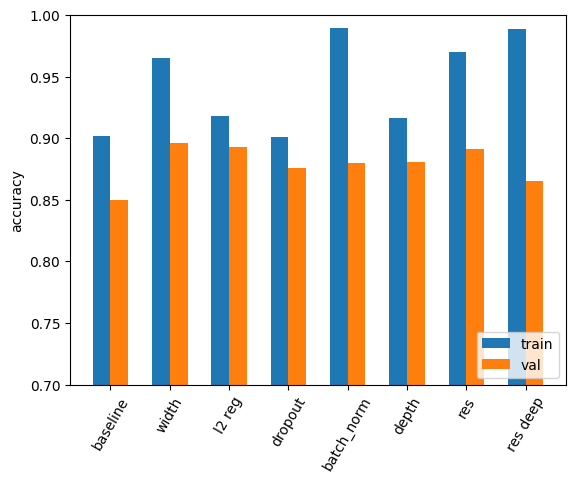

In [73]:
trn_acc = [v["train"] for k, v in all_acc_dict.items()]
val_acc = [v["val"] for k, v in all_acc_dict.items()]

width = 0.3
plt.bar(np.arange(len(trn_acc)), trn_acc, width=width, label="train")
plt.bar(np.arange(len(val_acc)) + width, val_acc, width=width, label="val")
plt.xticks(np.arange(len(val_acc)) + width / 2, list(all_acc_dict.keys()), rotation=60)
plt.ylabel("accuracy")
plt.legend(loc="lower right")
plt.ylim(0.7, 1)
plt.show()